Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split

Load a CSV File

In [2]:
import pandas as pd

df = pd.read_csv('/content/energy_data.csv')
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,0.152,0.124,241.20,0.8,0,0,1,8/16/2008 13:14
1,0.242,0.000,239.55,1.0,0,0,1,1/29/2010 21:36
2,0.334,0.072,243.01,1.6,0,0,1,9/5/2010 17:46
3,1.350,0.000,242.27,5.6,0,0,19,3/26/2010 9:52
4,1.404,0.206,238.85,5.8,0,0,18,9/15/2009 11:41


Assign the Target Variable

In [3]:
target = 'Global_active_power'

X = df.drop(['datetime', target], axis=1)
y = df[target]

In [4]:
print(X.shape, y.shape)
X.head()

(50000, 6) (50000,)


,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0.124,241.20,0.8,0,0,1
1,0.000,239.55,1.0,0,0,1
2,0.072,243.01,1.6,0,0,1
3,0.000,242.27,5.6,0,0,19
4,0.206,238.85,5.8,0,0,18


Train the Model

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(40000, 6) (10000, 6)


Random Forest

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Decision Tree

In [7]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

MAE AND RMSE

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [9]:
rf_metrics = evaluate(y_test, rf_pred)
dt_metrics = evaluate(y_test, dt_pred)

print("Random Forest (MAE, RMSE, R2):", rf_metrics)
print("Decision Tree (MAE, RMSE, R2):", dt_metrics)

Random Forest (MAE, RMSE, R2): (0.020692897796825396, np.float64(0.03647208427764959), 0.9988503683454942)
Decision Tree (MAE, RMSE, R2): (0.026386950000000003, np.float64(0.047251577251746606), 0.9980703872172919)


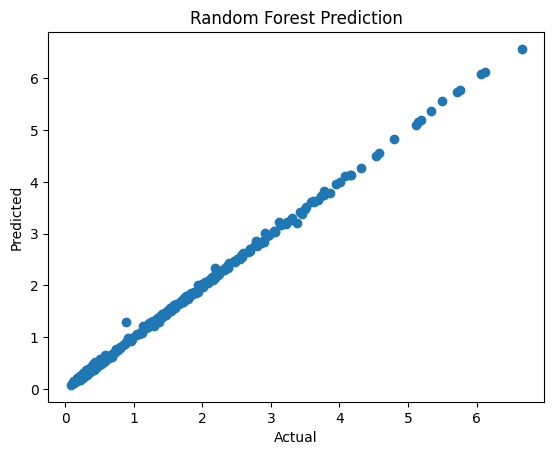

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test[:500], rf_pred[:500])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Prediction")
plt.show()

Train Federated Learning

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
data = pd.read_csv("energy_data.csv")

# Convert datetime
data['datetime'] = pd.to_datetime(data['datetime'])
data['hour'] = data['datetime'].dt.hour
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month

data = data.drop(columns=['datetime'])

# Fill missing values
data = data.fillna(data.mean())

# Features & target
X = data.drop(columns=['Global_active_power'])
y = data['Global_active_power']   # IMPORTANT: single bracket

# Normalize only X
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Data ready")

Data ready


In [13]:
num_clients = 10
client_data = []

# Convert y_train to numpy (IMPORTANT)
y_train_np = np.array(y_train)

# Split size
split_size = len(X_train) // num_clients

for i in range(num_clients):
    start = i * split_size
    end = (i + 1) * split_size

    X_c = X_train[start:end]
    y_c = y_train_np[start:end]   # use numpy version

    client_data.append((X_c, y_c))

print("Number of clients:", len(client_data))
print("Sample client shape:", client_data[0][0].shape, client_data[0][1].shape)

Number of clients: 10
Sample client shape: (4000, 9) (4000,)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def create_model():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

Fedavg

In [26]:
def fedavg(weights_list):
    return [np.mean(w, axis=0) for w in zip(*weights_list)]

In [21]:
def train_fedavg():
    global_model = create_model()
    global_weights = global_model.get_weights()

    loss_list, mae_list, rmse_list = [], [], []
    y_test_np = np.array(y_test).reshape(-1)

    for r in range(30):
        client_weights_list = []

        for X_c, y_c in client_data:
            local_model = create_model()
            local_model.set_weights(global_weights)

            local_model.fit(X_c, y_c, epochs=1, verbose=0)
            client_weights_list.append(local_model.get_weights())

        # Aggregation
        global_weights = fedavg(client_weights_list)
        global_model.set_weights(global_weights)

        # Evaluation
        y_pred = global_model.predict(X_test, verbose=0).reshape(-1)

        loss = mean_squared_error(y_test_np, y_pred)
        mae = np.mean(np.abs(y_test_np - y_pred))
        rmse = np.sqrt(loss)

        loss_list.append(loss)
        mae_list.append(mae)
        rmse_list.append(rmse)

        print(f"FedAvg Round {r+1}: Loss={loss:.4f}, MAE={mae:.4f}")

    return loss_list, mae_list, rmse_list

Fedprox

In [22]:
def fedprox(global_w, local_w, mu=0.01):
    return [lw - mu * (lw - gw) for gw, lw in zip(global_w, local_w)]

In [23]:
def train_fedprox():
    global_model = create_model()
    global_weights = global_model.get_weights()

    loss_list, mae_list, rmse_list = [], [], []
    y_test_np = np.array(y_test).reshape(-1)

    for r in range(30):
        client_weights_list = []

        for X_c, y_c in client_data:
            local_model = create_model()
            local_model.set_weights(global_weights)

            local_model.fit(X_c, y_c, epochs=1, verbose=0)
            weights = local_model.get_weights()

            # Apply FedProx
            weights = fedprox(global_weights, weights)

            client_weights_list.append(weights)

        global_weights = fedavg(client_weights_list)
        global_model.set_weights(global_weights)

        y_pred = global_model.predict(X_test, verbose=0).reshape(-1)

        loss = mean_squared_error(y_test_np, y_pred)
        mae = np.mean(np.abs(y_test_np - y_pred))
        rmse = np.sqrt(loss)

        loss_list.append(loss)
        mae_list.append(mae)
        rmse_list.append(rmse)

        print(f"FedProx Round {r+1}: Loss={loss:.4f}, MAE={mae:.4f}")

    return loss_list, mae_list, rmse_list

fedsgd

In [24]:
def train_fedsgd():
    global_model = create_model()
    global_weights = global_model.get_weights()

    loss_list, mae_list, rmse_list = [], [], []
    y_test_np = np.array(y_test).reshape(-1)

    for r in range(30):
        client_weights_list = []

        for X_c, y_c in client_data:
            local_model = create_model()
            local_model.set_weights(global_weights)

            # SGD style: full batch
            local_model.fit(X_c, y_c, epochs=1, batch_size=len(X_c), verbose=0)
            client_weights_list.append(local_model.get_weights())

        global_weights = fedavg(client_weights_list)
        global_model.set_weights(global_weights)

        y_pred = global_model.predict(X_test, verbose=0).reshape(-1)

        loss = mean_squared_error(y_test_np, y_pred)
        mae = np.mean(np.abs(y_test_np - y_pred))
        rmse = np.sqrt(loss)

        loss_list.append(loss)
        mae_list.append(mae)
        rmse_list.append(rmse)

        print(f"FedSGD Round {r+1}: Loss={loss:.4f}, MAE={mae:.4f}")

    return loss_list, mae_list, rmse_list

In [27]:
fedavg_loss, fedavg_mae, fedavg_rmse = train_fedavg()

FedAvg Round 1: Loss=0.0528, MAE=0.1670
FedAvg Round 2: Loss=0.0130, MAE=0.0863
FedAvg Round 3: Loss=0.0057, MAE=0.0560
FedAvg Round 4: Loss=0.0037, MAE=0.0436
FedAvg Round 5: Loss=0.0030, MAE=0.0385
FedAvg Round 6: Loss=0.0028, MAE=0.0367
FedAvg Round 7: Loss=0.0024, MAE=0.0336
FedAvg Round 8: Loss=0.0022, MAE=0.0323
FedAvg Round 9: Loss=0.0021, MAE=0.0311
FedAvg Round 10: Loss=0.0020, MAE=0.0300
FedAvg Round 11: Loss=0.0019, MAE=0.0290
FedAvg Round 12: Loss=0.0019, MAE=0.0293
FedAvg Round 13: Loss=0.0019, MAE=0.0295
FedAvg Round 14: Loss=0.0018, MAE=0.0274
FedAvg Round 15: Loss=0.0017, MAE=0.0275
FedAvg Round 16: Loss=0.0017, MAE=0.0268
FedAvg Round 17: Loss=0.0016, MAE=0.0263
FedAvg Round 18: Loss=0.0016, MAE=0.0259
FedAvg Round 19: Loss=0.0016, MAE=0.0260
FedAvg Round 20: Loss=0.0016, MAE=0.0257
FedAvg Round 21: Loss=0.0015, MAE=0.0247
FedAvg Round 22: Loss=0.0015, MAE=0.0248
FedAvg Round 23: Loss=0.0014, MAE=0.0244
FedAvg Round 24: Loss=0.0014, MAE=0.0247
FedAvg Round 25: Loss=0.0

In [28]:
fedprox_loss, fedprox_mae, fedprox_rmse = train_fedprox()

FedProx Round 1: Loss=0.0560, MAE=0.1733
FedProx Round 2: Loss=0.0118, MAE=0.0812
FedProx Round 3: Loss=0.0062, MAE=0.0572
FedProx Round 4: Loss=0.0044, MAE=0.0478
FedProx Round 5: Loss=0.0036, MAE=0.0426
FedProx Round 6: Loss=0.0030, MAE=0.0390
FedProx Round 7: Loss=0.0027, MAE=0.0366
FedProx Round 8: Loss=0.0025, MAE=0.0349
FedProx Round 9: Loss=0.0023, MAE=0.0329
FedProx Round 10: Loss=0.0022, MAE=0.0330
FedProx Round 11: Loss=0.0020, MAE=0.0303
FedProx Round 12: Loss=0.0020, MAE=0.0304
FedProx Round 13: Loss=0.0018, MAE=0.0288
FedProx Round 14: Loss=0.0018, MAE=0.0280
FedProx Round 15: Loss=0.0019, MAE=0.0298
FedProx Round 16: Loss=0.0017, MAE=0.0272
FedProx Round 17: Loss=0.0016, MAE=0.0267
FedProx Round 18: Loss=0.0016, MAE=0.0263
FedProx Round 19: Loss=0.0017, MAE=0.0274
FedProx Round 20: Loss=0.0016, MAE=0.0254
FedProx Round 21: Loss=0.0015, MAE=0.0252
FedProx Round 22: Loss=0.0015, MAE=0.0251
FedProx Round 23: Loss=0.0015, MAE=0.0247
FedProx Round 24: Loss=0.0015, MAE=0.0242
F

In [29]:
fedsgd_loss, fedsgd_mae, fedsgd_rmse = train_fedsgd()

FedSGD Round 1: Loss=1.5420, MAE=0.8458
FedSGD Round 2: Loss=1.3934, MAE=0.7957
FedSGD Round 3: Loss=1.2551, MAE=0.7491
FedSGD Round 4: Loss=1.1273, MAE=0.7063
FedSGD Round 5: Loss=1.0103, MAE=0.6679
FedSGD Round 6: Loss=0.9037, MAE=0.6343
FedSGD Round 7: Loss=0.8068, MAE=0.6045
FedSGD Round 8: Loss=0.7187, MAE=0.5770
FedSGD Round 9: Loss=0.6388, MAE=0.5505
FedSGD Round 10: Loss=0.5663, MAE=0.5245
FedSGD Round 11: Loss=0.5007, MAE=0.4988
FedSGD Round 12: Loss=0.4417, MAE=0.4733
FedSGD Round 13: Loss=0.3887, MAE=0.4473
FedSGD Round 14: Loss=0.3414, MAE=0.4209
FedSGD Round 15: Loss=0.2993, MAE=0.3947
FedSGD Round 16: Loss=0.2623, MAE=0.3689
FedSGD Round 17: Loss=0.2301, MAE=0.3441
FedSGD Round 18: Loss=0.2027, MAE=0.3213
FedSGD Round 19: Loss=0.1795, MAE=0.3007
FedSGD Round 20: Loss=0.1603, MAE=0.2828
FedSGD Round 21: Loss=0.1445, MAE=0.2678
FedSGD Round 22: Loss=0.1315, MAE=0.2554
FedSGD Round 23: Loss=0.1207, MAE=0.2453
FedSGD Round 24: Loss=0.1115, MAE=0.2372
FedSGD Round 25: Loss=0.1

Hybrid Model

In [30]:
def train_hybrid():
    global_model = create_model()
    global_weights = global_model.get_weights()

    loss_list, mae_list, rmse_list = [], [], []
    y_test_np = np.array(y_test).reshape(-1)

    for r in range(30):
        client_weights_list = []

        for X_c, y_c in client_data:
            local_model = create_model()
            local_model.set_weights(global_weights)

            local_model.fit(X_c, y_c, epochs=1, verbose=0)
            weights = local_model.get_weights()

            # Hybrid logic
            if r >= 15:
                weights = fedprox(global_weights, weights)

            client_weights_list.append(weights)

        # Aggregation (same FedAvg)
        global_weights = fedavg(client_weights_list)
        global_model.set_weights(global_weights)

        # Evaluation
        y_pred = global_model.predict(X_test, verbose=0).reshape(-1)

        loss = mean_squared_error(y_test_np, y_pred)
        mae = np.mean(np.abs(y_test_np - y_pred))
        rmse = np.sqrt(loss)

        loss_list.append(loss)
        mae_list.append(mae)
        rmse_list.append(rmse)

        print(f"Hybrid Round {r+1}: Loss={loss:.4f}, MAE={mae:.4f}")

    return loss_list, mae_list, rmse_list

In [31]:
hybrid_loss, hybrid_mae, hybrid_rmse = train_hybrid()

Hybrid Round 1: Loss=0.0476, MAE=0.1570
Hybrid Round 2: Loss=0.0097, MAE=0.0722
Hybrid Round 3: Loss=0.0053, MAE=0.0522
Hybrid Round 4: Loss=0.0037, MAE=0.0432
Hybrid Round 5: Loss=0.0029, MAE=0.0384
Hybrid Round 6: Loss=0.0025, MAE=0.0347
Hybrid Round 7: Loss=0.0022, MAE=0.0324
Hybrid Round 8: Loss=0.0020, MAE=0.0309
Hybrid Round 9: Loss=0.0019, MAE=0.0297
Hybrid Round 10: Loss=0.0018, MAE=0.0288
Hybrid Round 11: Loss=0.0017, MAE=0.0279
Hybrid Round 12: Loss=0.0016, MAE=0.0273
Hybrid Round 13: Loss=0.0016, MAE=0.0259
Hybrid Round 14: Loss=0.0016, MAE=0.0259
Hybrid Round 15: Loss=0.0015, MAE=0.0253
Hybrid Round 16: Loss=0.0015, MAE=0.0254
Hybrid Round 17: Loss=0.0015, MAE=0.0247
Hybrid Round 18: Loss=0.0014, MAE=0.0243
Hybrid Round 19: Loss=0.0014, MAE=0.0244
Hybrid Round 20: Loss=0.0014, MAE=0.0236
Hybrid Round 21: Loss=0.0014, MAE=0.0237
Hybrid Round 22: Loss=0.0014, MAE=0.0239
Hybrid Round 23: Loss=0.0013, MAE=0.0231
Hybrid Round 24: Loss=0.0014, MAE=0.0246
Hybrid Round 25: Loss=0.0

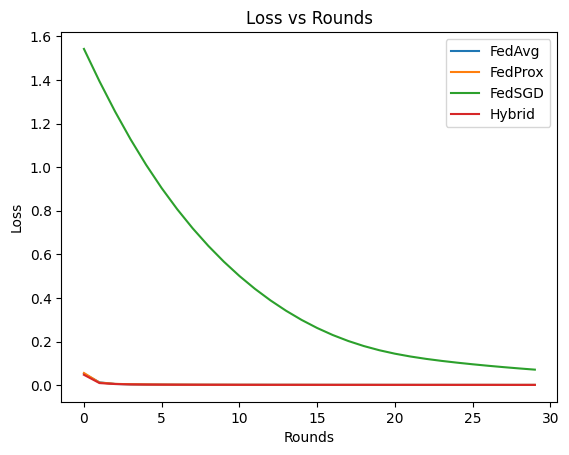

In [32]:
plt.figure()
plt.plot(fedavg_loss, label="FedAvg")
plt.plot(fedprox_loss, label="FedProx")
plt.plot(fedsgd_loss, label="FedSGD")
plt.plot(hybrid_loss, label="Hybrid")

plt.title("Loss vs Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.show()

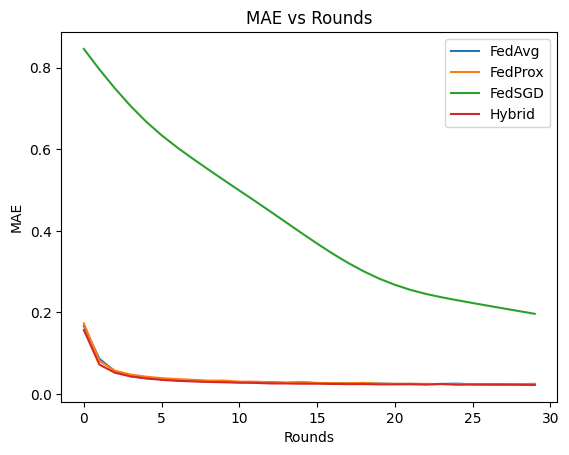

In [33]:
plt.figure()
plt.plot(fedavg_mae, label="FedAvg")
plt.plot(fedprox_mae, label="FedProx")
plt.plot(fedsgd_mae, label="FedSGD")
plt.plot(hybrid_mae, label="Hybrid")

plt.title("MAE vs Rounds")
plt.xlabel("Rounds")
plt.ylabel("MAE")
plt.legend()
plt.show()

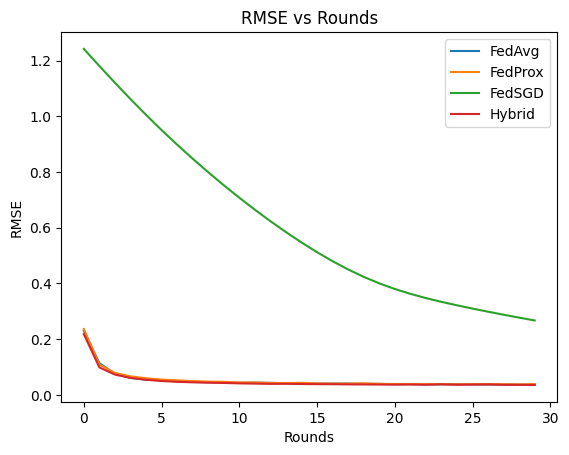

In [34]:
plt.figure()
plt.plot(fedavg_rmse, label="FedAvg")
plt.plot(fedprox_rmse, label="FedProx")
plt.plot(fedsgd_rmse, label="FedSGD")
plt.plot(hybrid_rmse, label="Hybrid")

plt.title("RMSE vs Rounds")
plt.xlabel("Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [35]:
print("\nFinal Results:\n")

print("FedAvg  -> MAE:", fedavg_mae[-1], " RMSE:", fedavg_rmse[-1])
print("FedProx -> MAE:", fedprox_mae[-1], " RMSE:", fedprox_rmse[-1])
print("FedSGD  -> MAE:", fedsgd_mae[-1], " RMSE:", fedsgd_rmse[-1])
print("Hybrid  -> MAE:", hybrid_mae[-1], " RMSE:", hybrid_rmse[-1])


Final Results:

FedAvg  -> MAE: 0.022975174852854014  RMSE: 0.03666585749500415
FedProx -> MAE: 0.025187075957596308  RMSE: 0.03870461475508917
FedSGD  -> MAE: 0.19660441564990433  RMSE: 0.26706055118558497
Hybrid  -> MAE: 0.022335859833443165  RMSE: 0.035730167131517415


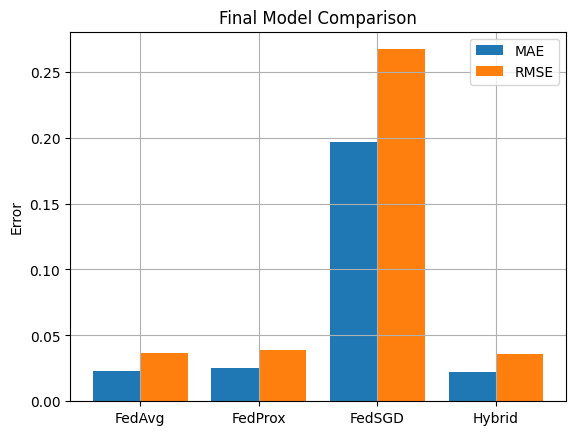

In [36]:
labels = ["FedAvg", "FedProx", "FedSGD", "Hybrid"]

final_mae = [
    fedavg_mae[-1],
    fedprox_mae[-1],
    fedsgd_mae[-1],
    hybrid_mae[-1]
]

final_rmse = [
    fedavg_rmse[-1],
    fedprox_rmse[-1],
    fedsgd_rmse[-1],
    hybrid_rmse[-1]
]

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, final_mae, width=0.4, label="MAE")
plt.bar(x + 0.2, final_rmse, width=0.4, label="RMSE")

plt.xticks(x, labels)
plt.title("Final Model Comparison")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

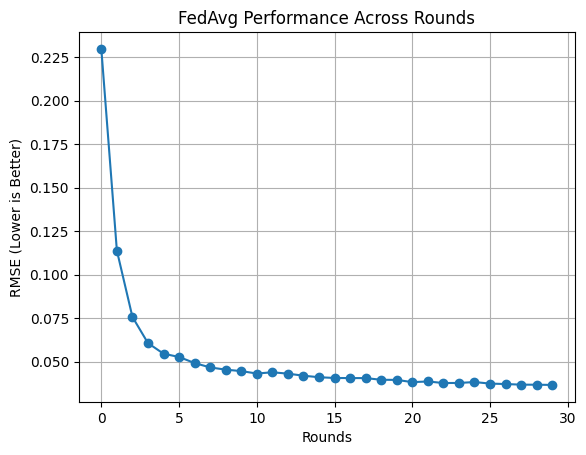

In [37]:
plt.figure()
plt.plot(fedavg_rmse, marker='o')
plt.title("FedAvg Performance Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("RMSE (Lower is Better)")
plt.grid()
plt.show()

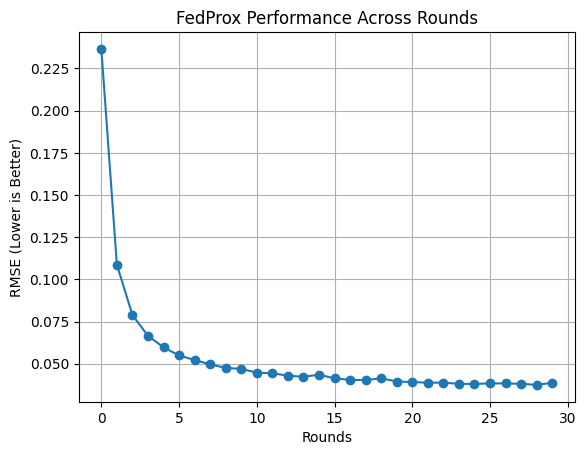

In [38]:
plt.figure()
plt.plot(fedprox_rmse, marker='o')
plt.title("FedProx Performance Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("RMSE (Lower is Better)")
plt.grid()
plt.show()

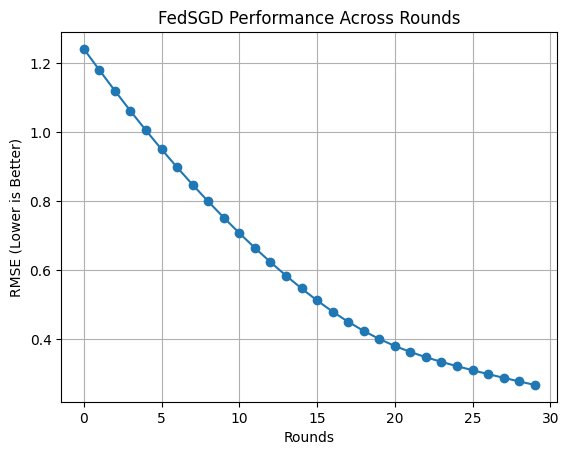

In [39]:
plt.figure()
plt.plot(fedsgd_rmse, marker='o')
plt.title("FedSGD Performance Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("RMSE (Lower is Better)")
plt.grid()
plt.show()

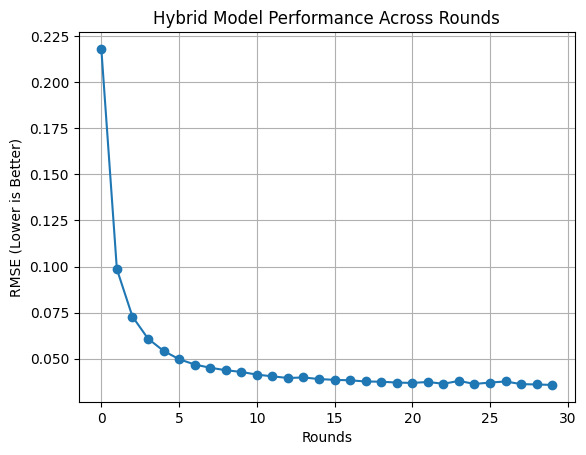

In [40]:
plt.figure()
plt.plot(hybrid_rmse, marker='o')
plt.title("Hybrid Model Performance Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("RMSE (Lower is Better)")
plt.grid()
plt.show()